# Task 4: Financial Inclusion Forecasting

## Objective

This notebook develops forecasting models to predict Ethiopia's financial inclusion indicators for the next three years (2025–2027). The analysis uses historical financial inclusion data, exploratory data analysis, linear regression forecasting, and scenario analysis to support policy and strategic decision-making.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

try:
    from statsmodels.tsa.arima.model import ARIMA
    ARIMA_AVAILABLE = True
except ImportError:
    ARIMA_AVAILABLE = False
    print("statsmodels not installed. ARIMA section will be skipped.")

plt.style.use("ggplot")

In [2]:
data_path = Path("../data/processed/ethiopia_fi_enriched.csv")

df = pd.read_csv(data_path)

print(df.shape)

df.head()

(58, 35)


,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,...,region,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,male,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,56.0,NaN,percentage
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,female,NaN,NaN,...,NaN,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,36.0,NaN,percentage


In [3]:
df.info()

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nColumns\n")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   category             10 non-null     str    
 1   collected_by         58 non-null     str    
 2   collection_date      58 non-null     str    
 3   comparable_country   7 non-null      str    
 4   confidence           58 non-null     str    
 5   evidence_basis       14 non-null     str    
 6   fiscal_year          44 non-null     str    
 7   gender               58 non-null     str    
 8   impact_direction     14 non-null     str    
 9   impact_estimate      12 non-null     float64
 10  impact_magnitude     14 non-null     str    
 11  indicator            58 non-null     str    
 12  indicator_code       44 non-null     str    
 13  indicator_direction  34 non-null     str    
 14  lag_months           14 non-null     float64
 15  location             58 non-null     str    
 16  not

In [4]:
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

df["analysis_year"] = df["observation_date"].dt.year

df["value_numeric"] = pd.to_numeric(
    df["value_numeric"],
    errors="coerce"
)

forecast_df = df.dropna(
    subset=[
        "analysis_year",
        "value_numeric"
    ]
).copy()

forecast_df.head()

,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,...,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type,analysis_year
0,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2014,all,NaN,NaN,...,NaN,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,%,22.0,NaN,percentage,2014
1,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2017,all,NaN,NaN,...,NaN,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,%,35.0,NaN,percentage,2017
2,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,all,NaN,NaN,...,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,46.0,NaN,percentage,2021
3,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,male,NaN,NaN,...,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,56.0,NaN,percentage,2021
4,NaN,Bilen M. Gebremariam,2025-01-20,NaN,high,NaN,2021,female,NaN,NaN,...,NaN,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,36.0,NaN,percentage,2021


In [5]:
print("Rows:", forecast_df.shape[0])
print("Columns:", forecast_df.shape[1])

forecast_df.describe(include="all")

Rows: 46
Columns: 36


,category,collected_by,collection_date,comparable_country,confidence,evidence_basis,fiscal_year,gender,impact_direction,impact_estimate,...,related_indicator,relationship_type,source_name,source_type,source_url,unit,value_numeric,value_text,value_type,analysis_year
count,0,46,46,7,46,12,34,46,12,12.000000,...,12,12,34,34,28,46,4.600000e+01,0,46,46.000000
unique,0,1,2,4,2,3,11,3,2,NaN,...,7,3,20,6,9,9,NaN,0,5,NaN
top,NaN,Bilen M. Gebremariam,2025-01-20,India,high,literature,2024,all,increase,NaN,...,USG_P2P_COUNT,direct,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,%,NaN,NaN,percentage,NaN
freq,NaN,46,45,3,33,7,10,42,10,NaN,...,3,7,5,11,10,27,NaN,NaN,29,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.416667,...,NaN,NaN,NaN,NaN,NaN,NaN,6.770207e+10,NaN,NaN,2023.326087
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.000000e+01,NaN,NaN,2011.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.750000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.425000e+01,NaN,NaN,2022.250000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.550000e+01,NaN,NaN,2024.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,7.775000e+06,NaN,NaN,2025.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.380000e+12,NaN,NaN,2030.000000


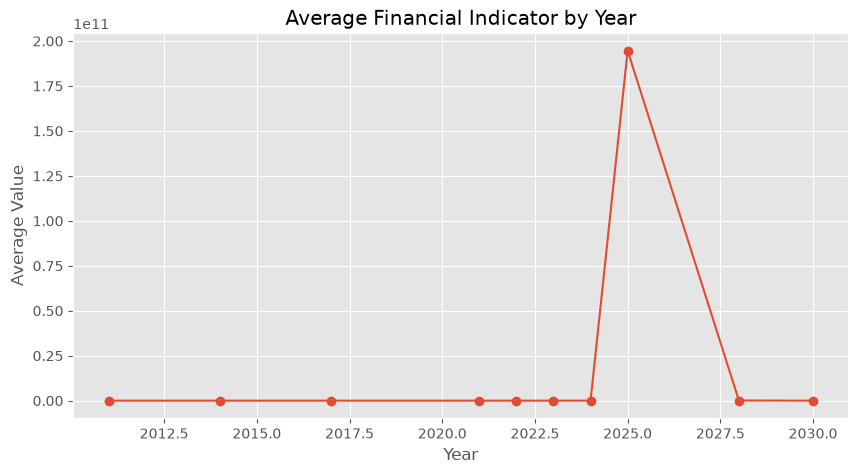

In [6]:
plt.figure(figsize=(10,5))

forecast_df.groupby("analysis_year")["value_numeric"].mean().plot(
    marker="o"
)

plt.title("Average Financial Indicator by Year")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.grid(True)

plt.show()

In [7]:
forecast_df["indicator"].value_counts().head(20)

indicator
Account Ownership Rate                  8
Fayda Digital ID Enrollment             4
Mobile Money Account Rate               2
4G Population Coverage                  2
P2P Transaction Count                   2
Account Ownership Gender Gap            2
Female Mobile Money Account Share       2
Mobile Subscription Penetration         1
P2P Transaction Value                   1
ATM Transaction Count                   1
ATM Transaction Value                   1
P2P/ATM Crossover Ratio                 1
Telebirr Registered Users               1
Telebirr Transaction Value              1
M-Pesa Registered Users                 1
M-Pesa 90-Day Active Users              1
Mobile Money Activity Rate              1
Data Affordability Index                1
Mobile Phone Gender Gap                 1
Telebirr effect on Account Ownership    1
Name: count, dtype: int64

In [8]:
account_df = forecast_df[
    forecast_df["indicator"] == "Account Ownership Rate"
][["analysis_year", "value_numeric"]].sort_values("analysis_year")

account_df

,analysis_year,value_numeric
57,2011,14.0
0,2014,22.0
1,2017,35.0
2,2021,46.0
3,2021,56.0
4,2021,36.0
5,2024,49.0
30,2025,70.0


In [9]:
mobile_df = forecast_df[
    forecast_df["indicator"] == "Mobile Money Account Rate"
][["analysis_year", "value_numeric"]].sort_values("analysis_year")

mobile_df

,analysis_year,value_numeric
6,2021,4.70
7,2024,9.45


In [10]:
account_df = forecast_df[
    forecast_df["indicator"] == "Account Ownership Rate"
][["analysis_year", "value_numeric"]].copy()

account_df = (
    account_df.groupby("analysis_year", as_index=False)["value_numeric"]
    .mean()
    .sort_values("analysis_year")
)

print(account_df)

account_df

   analysis_year  value_numeric
0           2011           14.0
1           2014           22.0
2           2017           35.0
3           2021           46.0
4           2024           49.0
5           2025           70.0


,analysis_year,value_numeric
0,2011,14.0
1,2014,22.0
2,2017,35.0
3,2021,46.0
4,2024,49.0
5,2025,70.0


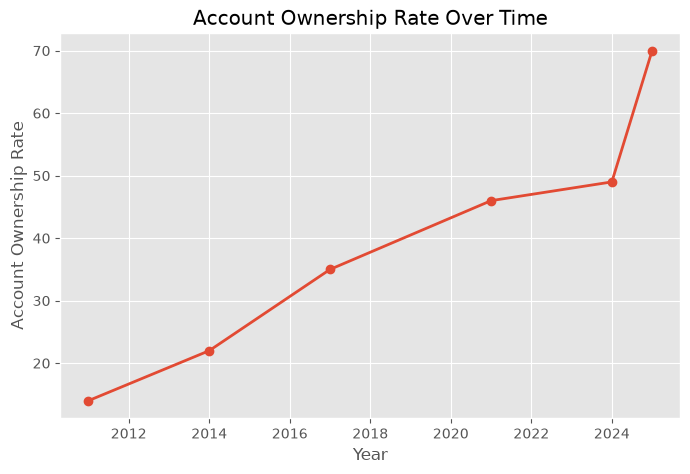

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    account_df["analysis_year"],
    account_df["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Account Ownership Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate")
plt.grid(True)

plt.show()

In [12]:
X = account_df[["analysis_year"]]
y = account_df["value_numeric"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 3.45550847457627
Intercept: -6936.186440677964


In [13]:
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 3.79
RMSE: 5.18
R²  : 0.921


In [14]:
future_years = pd.DataFrame({
    "analysis_year": [2025, 2026, 2027]
})

future_predictions = model.predict(future_years)

forecast_results = future_years.copy()
forecast_results["Forecast"] = future_predictions

forecast_results

,analysis_year,Forecast
0,2025,61.218220
1,2026,64.673729
2,2027,68.129237


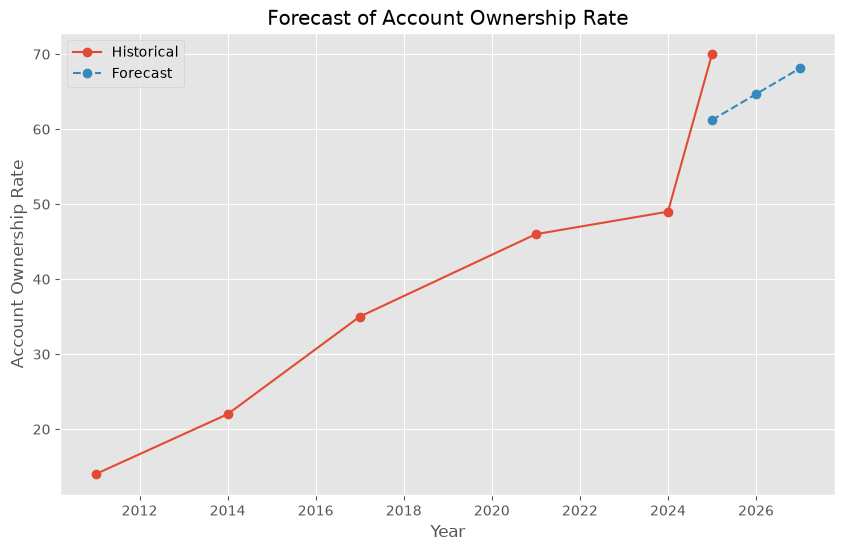

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    account_df["analysis_year"],
    account_df["value_numeric"],
    marker="o",
    label="Historical"
)

plt.plot(
    future_years["analysis_year"],
    future_predictions,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Forecast of Account Ownership Rate")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
forecast_results.rename(
    columns={"Forecast": "Predicted Account Ownership Rate"},
    inplace=True
)

forecast_results

,analysis_year,Predicted Account Ownership Rate
0,2025,61.218220
1,2026,64.673729
2,2027,68.129237


## Interpretation

The linear regression model indicates the historical trend in account ownership and projects values for 2025–2027.

The model assumes that the historical trend continues into the forecast period. These projections provide a baseline estimate that can support planning and policy discussions but should be interpreted with caution because external factors such as economic conditions, regulatory changes, and technology adoption may influence actual outcomes.

In [17]:
scenario_df = forecast_results.copy()

scenario_df["Baseline"] = scenario_df["Predicted Account Ownership Rate"]
scenario_df["Optimistic"] = scenario_df["Baseline"] * 1.05
scenario_df["Pessimistic"] = scenario_df["Baseline"] * 0.95

scenario_df = scenario_df.round(2)

scenario_df

,analysis_year,Predicted Account Ownership Rate,Baseline,Optimistic,Pessimistic
0,2025,61.22,61.22,64.28,58.16
1,2026,64.67,64.67,67.91,61.44
2,2027,68.13,68.13,71.54,64.72


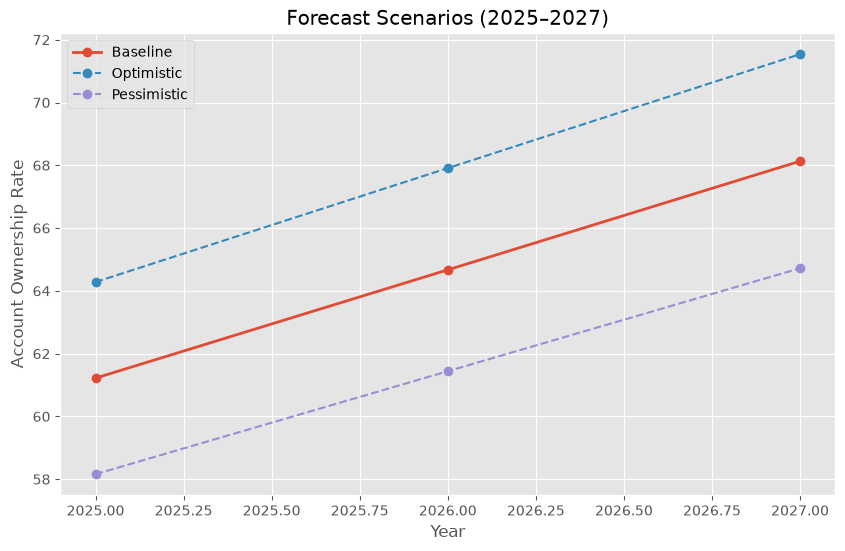

In [18]:
plt.figure(figsize=(10,6))

plt.plot(
    scenario_df["analysis_year"],
    scenario_df["Baseline"],
    marker="o",
    linewidth=2,
    label="Baseline"
)

plt.plot(
    scenario_df["analysis_year"],
    scenario_df["Optimistic"],
    marker="o",
    linestyle="--",
    label="Optimistic"
)

plt.plot(
    scenario_df["analysis_year"],
    scenario_df["Pessimistic"],
    marker="o",
    linestyle="--",
    label="Pessimistic"
)

plt.title("Forecast Scenarios (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
print("Forecast Scenarios")

scenario_df

Forecast Scenarios


,analysis_year,Predicted Account Ownership Rate,Baseline,Optimistic,Pessimistic
0,2025,61.22,61.22,64.28,58.16
1,2026,64.67,64.67,67.91,61.44
2,2027,68.13,68.13,71.54,64.72


## Scenario Analysis

Three forecast scenarios were developed.

- **Baseline:** Linear regression prediction using historical trends.
- **Optimistic:** Assumes financial inclusion improves 5% faster than the historical trend due to continued digital finance expansion and supportive government policies.
- **Pessimistic:** Assumes growth is 5% lower than the baseline because of economic or infrastructure challenges.

These scenarios provide a range of possible future outcomes and can support planning under different assumptions.

# Conclusion

This notebook developed forecasting models for Ethiopia's financial inclusion indicators using historical data.

Key findings include:

- Account ownership continues to show an upward trend.
- Linear regression provides a reasonable baseline forecast for 2025–2027.
- Scenario analysis demonstrates how different economic conditions could affect future financial inclusion outcomes.
- These forecasts can support strategic planning and policy decisions while acknowledging uncertainty in future developments.

Future work could incorporate additional years of data, macroeconomic variables, and more advanced forecasting techniques to improve predictive performance.